In [343]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

1: Data Loading & Understanding

In [344]:
df=pd.read_csv("Breast Cancer Prediction.csv")

In [345]:
type(df)
df

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
678,776715,3,1,1,1,3,2,1,1,1,2
679,841769,2,1,1,1,2,1,1,1,1,2
680,888820,5,10,10,3,7,3,8,10,2,4
681,897471,4,8,6,4,3,4,10,6,1,4


In [346]:
df['Class'].value_counts()

Class
2    444
4    239
Name: count, dtype: int64

In [347]:
df.shape

(683, 11)

In [348]:
df.columns

Index(['Sample code number', 'Clump Thickness', 'Uniformity of Cell Size',
       'Uniformity of Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
       'Normal Nucleoli', 'Mitoses', 'Class'],
      dtype='object')

In [349]:
df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [350]:
x=df.drop('Class', axis=1)
y=df['Class']

In [351]:
print(y.value_counts())

Class
2    444
4    239
Name: count, dtype: int64


2: Data Preprocessing

In [352]:
df.isnull().sum()

Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

In [353]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Sample code number           683 non-null    int64
 1   Clump Thickness              683 non-null    int64
 2   Uniformity of Cell Size      683 non-null    int64
 3   Uniformity of Cell Shape     683 non-null    int64
 4   Marginal Adhesion            683 non-null    int64
 5   Single Epithelial Cell Size  683 non-null    int64
 6   Bare Nuclei                  683 non-null    int64
 7   Bland Chromatin              683 non-null    int64
 8   Normal Nucleoli              683 non-null    int64
 9   Mitoses                      683 non-null    int64
 10  Class                        683 non-null    int64
dtypes: int64(11)
memory usage: 58.8 KB


In [354]:
df.describe()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.830000e+02,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,1.076720e+06,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,6.206440e+05,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,6.337500e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.776170e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171795e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238705e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [355]:
df = df.drop('Sample code number', axis=1)
df

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
678,3,1,1,1,3,2,1,1,1,2
679,2,1,1,1,2,1,1,1,1,2
680,5,10,10,3,7,3,8,10,2,4
681,4,8,6,4,3,4,10,6,1,4


In [356]:
df.columns

Index(['Clump Thickness', 'Uniformity of Cell Size',
       'Uniformity of Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
       'Normal Nucleoli', 'Mitoses', 'Class'],
      dtype='object')

In [357]:
df=df.drop(['Mitoses'],axis=1)


In [358]:
df=df.drop(['Uniformity of Cell Size'],axis=1)

In [359]:
from sklearn.model_selection import train_test_split
x = df.drop('Class', axis=1)  
y = df['Class']                
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

from sklearn.preprocessing import  StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Train shape: (546, 7) (546,)
Test shape: (137, 7) (137,)


3.Exploratory Data Analysis (EDA) 

In [360]:
df.describe()

,Clump Thickness,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Class
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,2.699854
std,2.820761,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,0.954592
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,2.000000
75%,6.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


array([[<Axes: title={'center': 'Clump Thickness'}>,
        <Axes: title={'center': 'Uniformity of Cell Shape'}>,
        <Axes: title={'center': 'Marginal Adhesion'}>],
       [<Axes: title={'center': 'Single Epithelial Cell Size'}>,
        <Axes: title={'center': 'Bare Nuclei'}>,
        <Axes: title={'center': 'Bland Chromatin'}>],
       [<Axes: title={'center': 'Normal Nucleoli'}>,
        <Axes: title={'center': 'Class'}>, <Axes: >]], dtype=object)

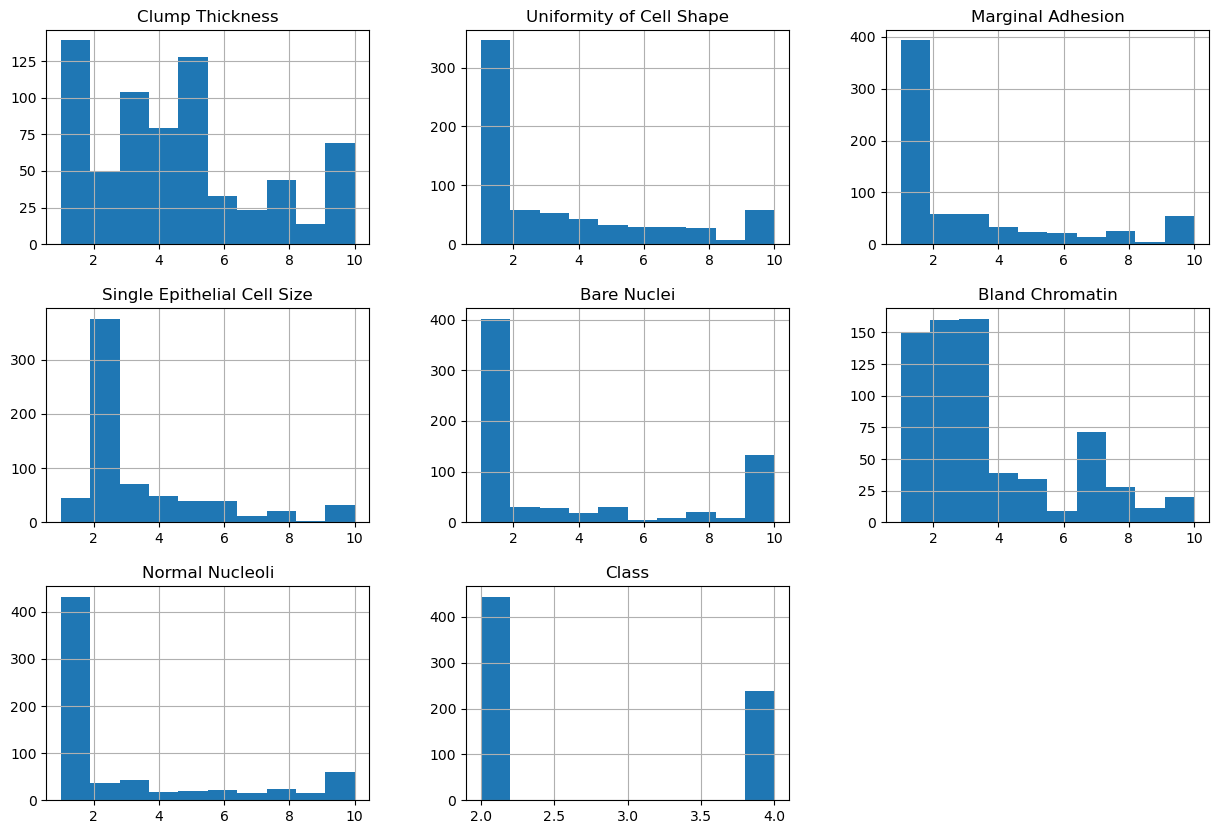

In [361]:
df.hist(figsize=(15,10))

<Axes: >

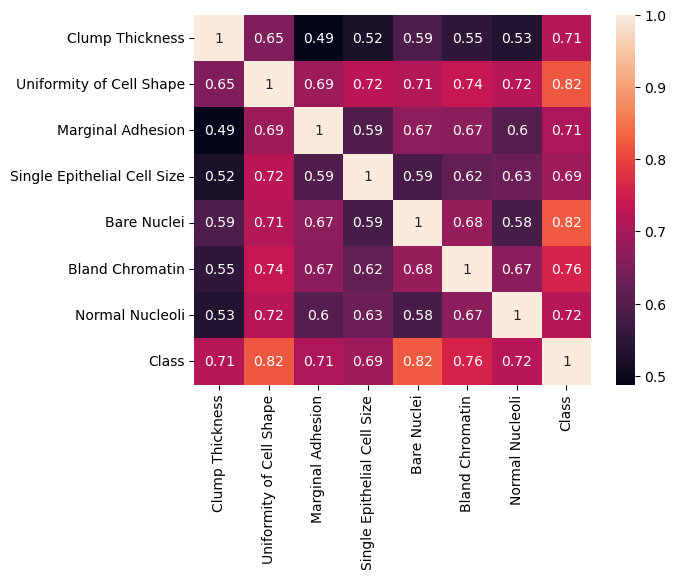

In [362]:
import seaborn as sns
sns.heatmap(df.corr(),annot=True)

5: Model Building

In [363]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(5)
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [364]:
y_pred=knn.predict(x_test)

6: Model Evaluation

In [365]:
from sklearn.metrics import accuracy_score,classification_report
print('accuracy_score:',accuracy_score(y_test,y_pred))

accuracy_score: 0.9562043795620438


In [366]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           2       0.94      0.99      0.96        79
           4       0.98      0.91      0.95        58

    accuracy                           0.96       137
   macro avg       0.96      0.95      0.95       137
weighted avg       0.96      0.96      0.96       137



In [367]:
df.head()

,Clump Thickness,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Class
0,5,1,1,2,1,3,1,2
1,5,4,5,7,10,3,2,2
2,3,1,1,2,2,3,1,2
3,6,8,1,3,4,3,7,2
4,4,1,3,2,1,3,1,2


In [368]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

print("SMOTE + KNN Report:\n", classification_report(y_test, y_pred))


SMOTE + KNN Report:
               precision    recall  f1-score   support

           2       0.99      0.99      0.99        85
           4       0.99      0.99      0.99        93

    accuracy                           0.99       178
   macro avg       0.99      0.99      0.99       178
weighted avg       0.99      0.99      0.99       178



7: Prediction on New Data

In [369]:
import warnings
warnings.filterwarnings('ignore')
new_sample = [[5, 1, 1, 2, 1, 3, 1]]
new_sample_scaled = scaler.transform(new_sample)
predicted_label = knn.predict(new_sample_scaled)
print("Predicted Label for new sample:", predicted_label)


Predicted Label for new sample: [2]


In [370]:
expected_labels = [2]
comparison = list(zip(expected_labels, predicted_label))
print("Expected vs Predicted:", comparison)


Expected vs Predicted: [(2, np.int64(2))]


8: K Value Comparison

In [371]:
k_values = [1, 3, 5, 7, 9]
accuracy_scores = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    accuracy_scores[k] = accuracy_score(y_test, y_pred)

print("Accuracy for each K:", accuracy_scores)

Accuracy for each K: {1: 0.9775280898876404, 3: 0.9831460674157303, 5: 0.9887640449438202, 7: 0.9887640449438202, 9: 0.9887640449438202}


9: Distance Metric Analysis

In [372]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
metrics = ['euclidean', 'manhattan', 'minkowski']

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    print(f"\nDistance Metric: {metric}")
    print(classification_report(y_test, y_pred))



Distance Metric: euclidean
              precision    recall  f1-score   support

           2       0.99      0.99      0.99        85
           4       0.99      0.99      0.99        93

    accuracy                           0.99       178
   macro avg       0.99      0.99      0.99       178
weighted avg       0.99      0.99      0.99       178


Distance Metric: manhattan
              precision    recall  f1-score   support

           2       0.99      0.99      0.99        85
           4       0.99      0.99      0.99        93

    accuracy                           0.99       178
   macro avg       0.99      0.99      0.99       178
weighted avg       0.99      0.99      0.99       178


Distance Metric: minkowski
              precision    recall  f1-score   support

           2       0.99      0.99      0.99        85
           4       0.99      0.99      0.99        93

    accuracy                           0.99       178
   macro avg       0.99      0.99      0.99 